# Explore Data

In [1]:
import pandas as pd
import yaml
from pathlib import Path

In [2]:
config_path = Path("../config.yaml")

with open(config_path, encoding="utf-8") as f:
        config = yaml.safe_load(f)

data_cfg = config["data"]

In [3]:
dataset = pd.read_pickle(Path("..") / data_cfg["dataset"]).iloc[:, :159]

In [4]:
dataset

KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2008-01-02 A          -0.929234  0.040555 -0.863206 -0.084937 -0.146137   
           AA         -0.837011  0.338060 -0.680520  1.317432  0.885237   
           AAPL       -2.007001  2.144158 -0.909185  0.296518 -0.441660   
           ABC         0.126140 -0.463399  0.156018  2.039001  2.889885   
           ABT        -0.571070  0.205625 -0.496077  1.304046  0.995287   
...                         ...       ...       ...       ...       ...   
2020-11-06 YUM        -1.083927  0.315733 -0.885198  0.803889  0.478897   
           ZBH        -0.833728  3.000000 -0.247752  3.000000  1.068273   
           ZBRA        1.597379  1.127629  0.915793  0.548642 -0.085478   
           ZION       -2.649179  2.830138 -1.024543  1.326173 -0.129881   
           ZTS        -1.452839  1.965148 -0.694572 -0.069017 -0.587244   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2008-01-02 A           0.153880  0.064511 -0.715385 -0.664945  0.939171  ...   
           AA         -0.181842 -0.365347 -1.125047 -0.908826  0.845077  ...   
           AAPL        1.799321  0.206171 -1.231990 -0.584574  2.053658  ...   
           ABC        -0.960592 -0.952313 -0.751889 -0.915618 -0.125975  ...   
           ABT         0.262400  0.067929 -0.768120 -0.663006  0.574836  ...   
...                         ...       ...       ...       ...       ...  ...   
2020-11-06 YUM        -0.451687 -0.581466 -1.269013 -1.031442  1.097450  ...   
           ZBH         3.000000  0.721280 -0.906076 -0.292326  0.841730  ...   
           ZBRA        0.095236 -0.388329  1.198651  0.656489 -1.569342  ...   
           ZION        0.673268 -0.419276 -2.384992 -0.939423  2.730971  ...   
           ZTS         3.000000  0.965154 -0.233091 -0.153963  1.477186  ...   

                        VSUMN10   VSUMN20   VSUMN30   VSUMN60    VSUMD5  \
datetime   instrument                                                     
2008-01-02 A           0.318017 -0.508168  3.000000 -0.346114  1.609807   
           AA          1.046747  0.034942  0.639179  0.499863  1.661954   
           AAPL       -0.157077 -0.347943  0.709385 -0.375654  1.647861   
           ABC         0.557199  1.551237  0.889867 -0.053082  1.314409   
           ABT        -0.140497  0.281644  0.304853  0.393836  2.929219   
...                         ...       ...       ...       ...       ...   
2020-11-06 YUM        -0.951803 -0.885182 -0.968131 -0.890119 -0.360750   
           ZBH        -1.984345 -2.089871 -3.000000 -3.000000  1.502762   
           ZBRA       -0.668757 -1.322638 -0.967345 -1.885625  0.446838   
           ZION        1.074483 -0.934956 -0.270655 -1.184427  0.034385   
           ZTS        -0.948843 -0.554779 -0.889249 -0.954520 -0.032822   

                        VSUMD10   VSUMD20   VSUMD30   VSUMD60  \
datetime   instrument                                           
2008-01-02 A          -0.319017  0.509791 -3.000000  0.347033   
           AA         -1.050048 -0.035045 -0.641114 -0.501193   
           AAPL        0.157576  0.349057 -0.711534  0.376651   
           ABC        -0.558954 -1.556161 -0.892569  0.053222   
           ABT         0.140944 -0.282532 -0.305765 -0.394882   
...                         ...       ...       ...       ...   
2020-11-06 YUM         0.954811  0.888004  0.971108  0.892483   
           ZBH         1.990612  2.096523  3.000000  3.000000   
           ZBRA        0.670871  1.326851  0.970321  1.890634   
           ZION       -1.077871  0.937937  0.271501  1.187574   
           ZTS         0.951841  0.556551  0.891986  0.957055   

                       Ref($close, -2)/Ref($close, -1) - 1  
datetime   instrument                                       
2008-01-02 A                                     -0.455263  
     

In [ ]:
# dataset.to_parquet("sp500dataset.parquet")

# MODULE

In [5]:
from scipy.stats import spearmanr


def compute_metrics(df, pred_col="score", target_col="LABEL0"):
    """
    Rank IC, ICIR, and precision@10% (FactorVAE-style).
    Assumes df has a MultiIndex (datetime, instrument).
    """

    def daily_rank_ic(group):
        return spearmanr(group[pred_col], group[target_col])[0]

    daily_ic = df.groupby(level="datetime").apply(daily_rank_ic)

    rank_ic_mean = daily_ic.mean()
    rank_ic_std = daily_ic.std()
    icir = rank_ic_mean / rank_ic_std if rank_ic_std != 0 else 0

    def daily_precision(group, k=0.1):
        n = len(group)
        top_k = int(n * k)
        if top_k == 0:
            return 0

        top_pred = group.nlargest(top_k, pred_col).index
        top_true = group.nlargest(top_k, target_col).index
        return len(set(top_pred) & set(top_true)) / top_k

    precision_at_10 = df.groupby(level="datetime").apply(daily_precision).mean()

    return {
        "Rank IC": rank_ic_mean,
        "Rank ICIR": icir,
        "Precision@10%": precision_at_10,
        "IC_Series": daily_ic,
    }


# MOVING AVERAGE

In [6]:
import pandas as pd
import numpy as np

# 1. Sort the MultiIndex 
df = dataset.copy()
df = df.sort_index(level=['instrument', 'datetime'])

# 2. Define the Target Column
target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
pred_col = 'prediction_MA'

# 3. Create the Moving Average Baseline Prediction
window_size = 120
df[pred_col] = df.groupby(level='instrument')[target_col].transform(
    lambda x: x.shift(1).rolling(window=window_size).mean()
)

# 4. Filter for the Test Period
test_start = "2019-01-01"
test_end = "2019-12-31"

# Slice based on the 'datetime' level of your MultiIndex
test_df = df.loc[(df.index.get_level_values('datetime') >= test_start) & 
                 (df.index.get_level_values('datetime') <= test_end)].copy()

# Drop rows with NaN values in predictions or targets 
test_df = test_df.dropna(subset=[target_col, pred_col])

# 5. Evaluate using your custom function
# (Assuming compute_metrics is already defined in your environment)
ma_metrics = compute_metrics(
    df=test_df, 
    pred_col=pred_col, 
    target_col=target_col
)

# 6. Output the Results
print("\n" + "="*50)
print(f" MOVING AVERAGE ({window_size}-DAY) BASELINE RESULTS")
print(f" Test Period: {test_start} to {test_end}")
print("="*50)

for metric_name, value in ma_metrics.items():
    if metric_name != "IC_Series":  # Hide the daily series data from the printout
        print(f" {metric_name:<15}: {value:.5f}")
print("="*50)


 MOVING AVERAGE (120-DAY) BASELINE RESULTS
 Test Period: 2019-01-01 to 2019-12-31
 Rank IC        : -0.01071
 Rank ICIR      : -0.05374
 Precision@10%  : 0.08698


# LGBM

Training LightGBM Model with Train/Val Split...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.273662 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32784
[LightGBM] [Info] Number of data points in the train set: 962496, number of used features: 157
[LightGBM] [Info] Start training from score 0.004071
Training until validation scores don't improve for 30 rounds
[10]	Train's l2: 0.997128	Validation's l2: 0.997605
[20]	Train's l2: 0.996725	Validation's l2: 0.997638
[30]	Train's l2: 0.996358	Validation's l2: 0.997672
Early stopping, best iteration is:
[8]	Train's l2: 0.997213	Validation's l2: 0.997581

 LIGHTGBM TEST RESULTS (Out-of-Sample)
 Test Period: 2019-01-01 to 2019-12-31
 Rank IC        : 0.00945
 Rank ICIR      : 0.05845
 Precision@10%  : 0.09083


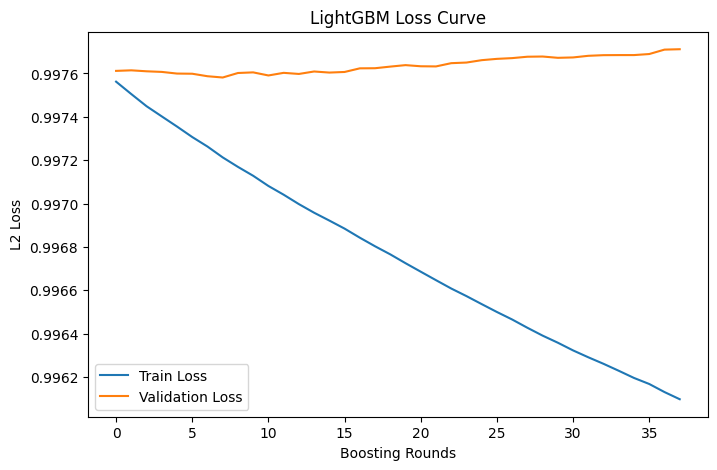

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


df = dataset.copy()
df = df.sort_index(level=['instrument', 'datetime'])

target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
exclude_cols = [target_col, 'prediction_MA20']
features = [col for col in df.columns if col not in exclude_cols]

df_clean = df.dropna(subset=[target_col] + features)

fit_start, fit_end = "2009-01-01", "2017-12-31"
val_start, val_end = "2018-01-01", "2018-12-31"
test_start, test_end = "2019-01-01", "2019-12-31"

dates = df_clean.index.get_level_values('datetime')

train_df = df_clean.loc[(dates >= fit_start) & (dates <= fit_end)].copy()
val_df = df_clean.loc[(dates >= val_start) & (dates <= val_end)].copy()
test_df = df_clean.loc[(dates >= test_start) & (dates <= test_end)].copy()

X_train, y_train = train_df[features], train_df[target_col]
X_val, y_val = val_df[features], val_df[target_col]
X_test, y_test = test_df[features], test_df[target_col]

print("Training LightGBM Model with Train/Val Split...")
model = lgb.LGBMRegressor(
    n_estimators=1000,       
    learning_rate=0.05, 
    num_leaves=15, 
    min_child_samples=50,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Train', 'Validation'],
    eval_metric='l2',
    callbacks=[
        early_stopping(stopping_rounds=30),
        log_evaluation(period=10)
    ]
)

test_df['prediction_LGBM'] = model.predict(X_test)

lgbm_metrics = compute_metrics(
    df=test_df, 
    pred_col='prediction_LGBM', 
    target_col=target_col
)

print("\n" + "="*45)
print(f" LIGHTGBM TEST RESULTS (Out-of-Sample)")
print(f" Test Period: {test_start} to {test_end}")
print("="*45)
for metric_name, value in lgbm_metrics.items():
    if metric_name != "IC_Series":  # ซ่อนรายวันไว้ก่อนเพื่อความสะอาดของ Output
        print(f" {metric_name:<15}: {value:.5f}")
print("="*45)

evals_result = model.evals_result_
plt.figure(figsize=(8, 5))
plt.plot(evals_result['Train']['l2'], label='Train Loss')
plt.plot(evals_result['Validation']['l2'], label='Validation Loss')
plt.title('LightGBM Loss Curve')
plt.xlabel('Boosting Rounds')
plt.ylabel('L2 Loss')
plt.legend()
plt.show()

# LINEAR

In [ ]:
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np

target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
exclude_cols = [target_col, 'prediction_MA20', 'prediction_LGBM'] 
features = [col for col in df.columns if col not in exclude_cols]

df_clean = df.dropna(subset=[target_col] + features).copy()

fit_start, fit_end = "2009-01-01", "2017-12-31"
test_start, test_end = "2019-01-01", "2019-12-31"

dates = df_clean.index.get_level_values('datetime')

train_mask = (dates >= fit_start) & (dates <= fit_end)
test_mask = (dates >= test_start) & (dates <= test_end)

X_train = df_clean.loc[train_mask, features]
y_train = df_clean.loc[train_mask, target_col]

X_test = df_clean.loc[test_mask, features]
y_test = df_clean.loc[test_mask, target_col]

print("Training Linear Model (Ridge Regression)...")
linear_model = Ridge(alpha=1.0, random_state=42)
linear_model.fit(X_train, y_train)

df_clean.loc[test_mask, 'prediction_Linear'] = linear_model.predict(X_test)

test_df_for_eval = df_clean[test_mask].copy()

linear_metrics = compute_metrics(
    df=test_df_for_eval, 
    pred_col='prediction_Linear', 
    target_col=target_col
)

print("\n" + "="*45)
print(f" LINEAR Baseline Results (Out-of-Sample)")
print(f" Test Period: {test_start} to {test_end}")
print("="*45)
for metric_name, value in linear_metrics.items():
    if metric_name != "IC_Series": # ซ่อนรายวันไว้ก่อน
        print(f" {metric_name:<15}: {value:.5f}")
print("="*45)

Training Linear Model (Ridge Regression)...

 LINEAR Baseline Results (Out-of-Sample)
 Test Period: 2019-01-01 to 2019-12-31
 Rank IC        : 0.00839
 Rank ICIR      : 0.06324
 Precision@10%  : 0.10460


# LSTM

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm

df = dataset.copy()
df = df.sort_index(level=['instrument', 'datetime'])

target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
exclude_cols = [target_col, 'prediction_MA20', 'prediction_LGBM', 'prediction_Linear']
features = [col for col in df.columns if col not in exclude_cols]

df_clean = df.dropna(subset=[target_col] + features).copy()

SEQ_LEN = 20 

def create_3d_sequences(df_group):
    """ฟังก์ชันสไลด์หน้าต่างข้อมูลทีละ 20 วัน สำหรับแต่ละหุ้น"""
    X_vals = df_group[features].values
    y_vals = df_group[target_col].values
    dates = df_group.index.get_level_values('datetime')
    
    X_seq, y_seq, seq_dates = [], [], []
    
    if len(X_vals) < SEQ_LEN:
        return None, None, None
        
    for i in range(len(X_vals) - SEQ_LEN + 1):
        X_seq.append(X_vals[i : i + SEQ_LEN])
        y_seq.append(y_vals[i + SEQ_LEN - 1])
        seq_dates.append(dates[i + SEQ_LEN - 1])
        
    return np.array(X_seq), np.array(y_seq), seq_dates

print(f"Generating 3D Sequences (T={SEQ_LEN}). This may take a moment...")
X_all, y_all, dates_all, instruments_all = [], [], [], []

for instrument, group in tqdm(df_clean.groupby(level='instrument')):
    X_seq, y_seq, val_dates = create_3d_sequences(group)
    if X_seq is not None:
        X_all.append(X_seq)
        y_all.append(y_seq)
        dates_all.extend(val_dates)
        instruments_all.extend([instrument] * len(val_dates))

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)
dates_all = np.array(dates_all)

Generating 3D Sequences (T=20). This may take a moment...


100%|██████████| 618/618 [01:25<00:00,  7.19it/s]


In [ ]:
# ==========================================
# 3. แบ่ง Train, Val, Test (ตาม Timeline)
# ==========================================
dates_all = pd.to_datetime(dates_all)

fit_start, fit_end = "2009-01-01", "2017-12-31"
val_start, val_end = "2018-01-01", "2018-12-31"
test_start, test_end = "2019-01-01", "2019-12-31"

train_mask = (dates_all >= fit_start) & (dates_all <= fit_end)
val_mask = (dates_all >= val_start) & (dates_all <= val_end)
test_mask = (dates_all >= test_start) & (dates_all <= test_end)

def create_dataloader(X, y, batch_size=512, shuffle=False):
    tensor_x = torch.tensor(X, dtype=torch.float32)
    tensor_y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = create_dataloader(X_all[train_mask], y_all[train_mask], batch_size=4096, shuffle=True)
val_loader = create_dataloader(X_all[val_mask], y_all[val_mask], batch_size=4096, shuffle=False)
test_loader = create_dataloader(X_all[test_mask], y_all[test_mask], batch_size=4096, shuffle=False)

In [ ]:
# ==========================================
# 4. สร้างสถาปัตยกรรม LSTM
# ==========================================
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, 
                            hidden_size=hidden_size, 
                            num_layers=num_layers, 
                            batch_first=True, 
                            dropout=0.2)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        predictions = self.linear(last_time_step)
        return predictions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

model = LSTMModel(
    input_size=len(features), 
    hidden_size=32,    
    num_layers=1       
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# ==========================================
# 5. Training Loop + Early Stopping
# ==========================================
epochs = 10
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0

print("Training LSTM Model...")
for epoch in range(epochs):
    
    print(f"Current Epoch : {epoch}")
    
    model.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, targets).item() * inputs.size(0)
    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch {epoch+1:02d} | Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered!")
            break


Using device: cuda
Training LSTM Model...
Current Epoch : 0


c:\Users\Nirawit EN\anaconda3\envs\Ai\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 01 | Val Loss: 1.001736
Current Epoch : 1
Epoch 02 | Val Loss: 1.001387
Current Epoch : 2
Epoch 03 | Val Loss: 1.000163
Current Epoch : 3
Epoch 04 | Val Loss: 1.000747
Current Epoch : 4


KeyboardInterrupt: 

In [14]:
# ==========================================
# 6. Evaluation (ใช้ compute_metrics)
# ==========================================
model.load_state_dict(torch.load('best_lstm_model.pth', weights_only=True))
model.eval()

predictions = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predictions.extend(outputs.cpu().numpy().flatten())

idx_test = pd.MultiIndex.from_arrays(
    [dates_all[test_mask], np.array(instruments_all)[test_mask]], 
    names=['datetime', 'instrument']
)
test_df_eval = pd.DataFrame({
    target_col: y_all[test_mask],
    'prediction_LSTM': predictions
}, index=idx_test)

test_df_eval = test_df_eval[~test_df_eval.index.duplicated(keep='last')]

lstm_metrics = compute_metrics(
    df=test_df_eval, 
    pred_col='prediction_LSTM', 
    target_col=target_col
)

print("\n" + "="*45)
print(f" LSTM TEST RESULTS (Out-of-Sample)")
print(f" Test Period: {test_start} to {test_end}")
print("="*45)
for metric_name, value in lstm_metrics.items():
    if metric_name != "IC_Series":
        print(f" {metric_name:<15}: {value:.5f}")
print("="*45)


 LSTM TEST RESULTS (Out-of-Sample)
 Test Period: 2019-01-01 to 2019-12-31
 Rank IC        : -0.00622
 Rank ICIR      : -0.08192
 Precision@10%  : 0.10163


# SUMMARY

In [16]:
import pandas as pd
from IPython.display import display

# 1. รวบรวมข้อมูลจากทุก Metrics ให้อยู่ในรูปแบบ List of Dictionaries
# (ข้าม 'IC_Series' ไปเพราะเราต้องการแค่ตัวเลขสรุปผล)
results_data = [
    {"Model": "Moving Average (120)",
     "Rank IC": ma_metrics["Rank IC"],
     "Rank ICIR": ma_metrics["Rank ICIR"],
     "Precision@10%": ma_metrics["Precision@10%"]},
     
    {"Model": "Linear (Ridge)",
     "Rank IC": linear_metrics["Rank IC"],
     "Rank ICIR": linear_metrics["Rank ICIR"],
     "Precision@10%": linear_metrics["Precision@10%"]},
     
    {"Model": "LSTM",
     "Rank IC": lstm_metrics["Rank IC"],
     "Rank ICIR": lstm_metrics["Rank ICIR"],
     "Precision@10%": lstm_metrics["Precision@10%"]},
     
    {"Model": "LightGBM",
     "Rank IC": lgbm_metrics["Rank IC"],
     "Rank ICIR": lgbm_metrics["Rank ICIR"],
     "Precision@10%": lgbm_metrics["Precision@10%"]}
]

# 2. แปลงเป็น DataFrame และตั้งชื่อโมเดลเป็น Index
results_df = pd.DataFrame(results_data).set_index("Model")

# 3. สร้างฟังก์ชันสำหรับ Highlight ค่าที่ดีที่สุดในแต่ละคอลัมน์
def highlight_best(s):
    # สำหรับ Rank IC และ ICIR: ค่าที่ดีที่สุดคือค่าที่ห่างจาก 0 มากที่สุด (ใช้ Absolute)
    # if s.name in ["Rank IC", "Rank ICIR"]:
    #     is_best = s.abs() == s.abs().max()
    # # สำหรับ Precision: ค่าที่ดีที่สุดคือค่าที่สูงที่สุดปกติ
    # else:
    is_best = s == s.max()
        
    # คืนค่า CSS สำหรับทำสีพื้นหลังสีเขียวและตัวหนา ให้กับช่องที่เป็น is_best
    return ['background-color: #90EE90; font-weight: bold; color: black' if v else '' for v in is_best]

# 4. แสดงผลแบบตาราง Highlight
styled_df = results_df.style.apply(highlight_best).format("{:.5f}")

print("\n" + "="*50)
print(" 🏆 OVERALL BASELINE MODELS PERFORMANCE 🏆")
print("="*50)
display(styled_df)


 🏆 OVERALL BASELINE MODELS PERFORMANCE 🏆


,Rank IC,Rank ICIR,Precision@10%
Model,,,
Moving Average (120),-0.01071,-0.05374,0.08698
Linear (Ridge),0.00839,0.06324,0.10460
LSTM,-0.00622,-0.08192,0.10163
LightGBM,0.00945,0.05845,0.09083
